# Punto 10 — Modelo conjunto VAR

Un **VAR** predice cada serie a partir de valores anteriores de todas las series. Así, los viajes pueden depender de viajes anteriores y también del clima de días previos. Se incluyen las cuatro variables.

Su forma es $z_t=c+A_1z_{t-1}+\cdots+A_pz_{t-p}+u_t$. El vector $z_t$ contiene las cuatro series; las matrices $A$ reúnen sus relaciones; **p** es la cantidad de días anteriores utilizados.

## Preparación

El VAR necesita series con un comportamiento relativamente estable. Antes de estimarlo, se retira de cada serie una parte de calendario: tendencia lineal, dos pares de senos y cosenos anuales y seis indicadores de día de la semana. Estos términos representan cambios suaves del año y diferencias entre días. Se estiman **solo con entrenamiento**. En viajes, KPSS todavía rechazó estacionariedad después de retirar el calendario (p≈0,024). Por eso se calcula una diferencia diaria adicional de sus residuos. Para las tres series climáticas se conservan los residuos sin diferencias. Luego se divide cada variable por su desvío para trabajar en escalas comparables.

Se aplican ADF y KPSS sobre esos residuos. ADF parte de la hipótesis de raíz unitaria; KPSS, de estacionariedad. La coincidencia de ambas pruebas respalda, pero no demuestra, la transformación. Sus p-valores son orientativos porque se aplican a residuos de un ajuste previo. No se aplica una diferencia anual automática: el punto 4 no la justificó para todas las series.

## Selección y evaluación

Se usa BIC para elegir entre **1 y 21 rezagos**. Se muestra también el rezago cero como referencia, pero se exige al menos uno para estudiar relaciones dinámicas. Los criterios se calculan con una ventana común. Luego se estima el orden elegido con todo el entrenamiento.

Se verifica estabilidad y se aplica una prueba conjunta de autocorrelación de residuos. La predicción de 2025 parte de diciembre de 2024; se vuelve a la escala original, se acumulan las diferencias de viajes desde el último residuo observado y se suma el calendario esperado. Ningún dato real de prueba entra en el pronóstico. También se ajusta el mismo orden con 2023–2025 para pronosticar enero de 2026.

Este procedimiento es una regresión de calendario seguida de un VAR de sus residuos. No es un VAR aplicado directamente a las series originales ni un modelo de cointegración.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/bicicletas_rosario.csv').exists())
if str(ROOT/'scripts') not in sys.path: sys.path.insert(0,str(ROOT/'scripts'))
from modelos_puntos56 import cargar, ajustar, ajustados, pronosticar, metricas, etiqueta
from modelos_resto import *
series=cargar(ROOT)
seleccion=json.loads((ROOT/'puntos/punto5/seleccion.json').read_text())
plt.rcParams.update({'figure.figsize':(11,4),'figure.dpi':120})


,serie,ADF_p,KPSS_p,compatible
0,Temperatura,6.343731e-15,0.10000,True
1,Humedad,2.903031e-21,0.09211,True
2,Precipitación,1.080008e-17,0.10000,True
3,Viajes MBTB,1.885258e-20,0.10000,True


,aic,bic,hqic,fpe
rezago,,,,
0,-0.354,-0.328,-0.344,0.702
1,-2.262,-2.134,-2.213,0.104
2,-2.494,-2.263,-2.405,0.083
3,-2.547,-2.212,-2.418,0.078
4,-2.572,-2.135,-2.403,0.076
5,-2.579,-2.038,-2.370,0.076
6,-2.592,-1.949,-2.344,0.075
7,-2.593,-1.846,-2.305,0.075
8,-2.576,-1.727,-2.248,0.076


,serie,MAE_SARIMA,RMSE_SARIMA,MAE_VAR,RMSE_VAR
0,Viajes MBTB,512.524,635.599,1441.181,1524.599
1,Temperatura,3.959,4.926,2.761,3.463
2,Humedad,11.474,13.611,9.440,11.769
3,Precipitación,4.770,10.350,5.266,10.442


**Se eligió VAR(2).** Estable: **True**. La prueba conjunta de autocorrelación tiene p=9.011e-05. Quedan relaciones entre residuos que el modelo no explicó.

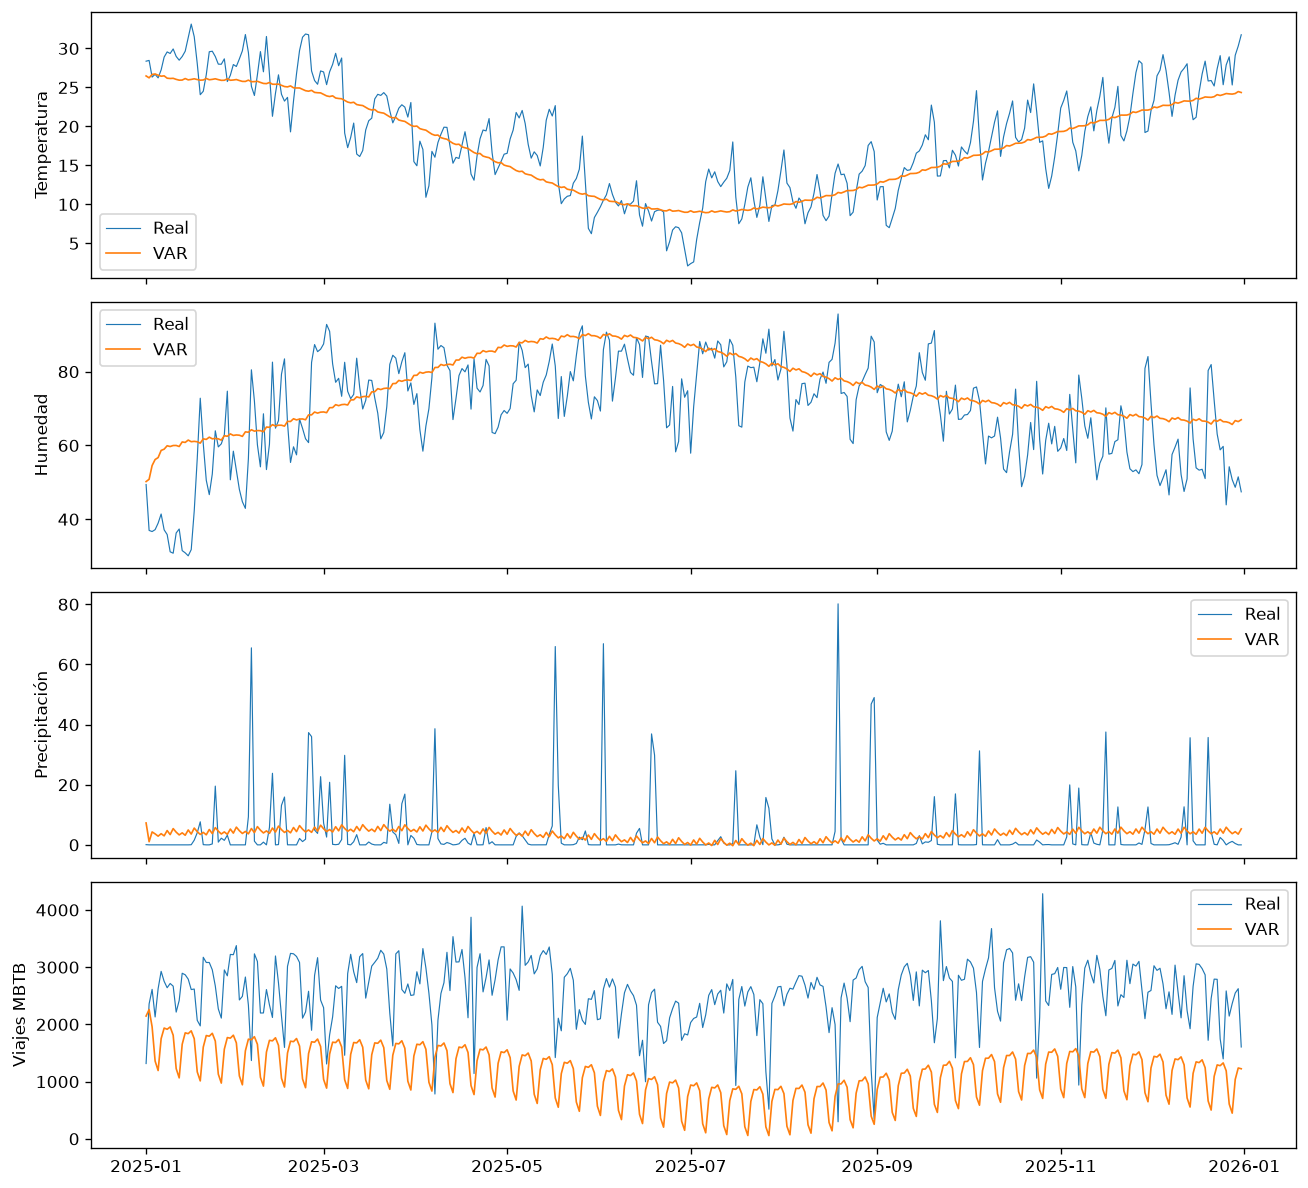

,Temperatura,Humedad,Precipitación,Viajes MBTB
2026-01-01,29.86,49.52,5.66,1852.86
2026-01-02,28.53,50.68,4.60,1782.64
2026-01-03,27.54,53.35,4.81,1136.16
2026-01-04,26.82,54.69,4.24,1058.86
2026-01-05,26.67,56.14,4.19,1542.52
2026-01-06,26.83,56.83,3.62,1707.32
2026-01-07,26.71,57.76,4.89,1676.66
2026-01-08,26.74,57.29,3.45,1741.66
2026-01-09,26.85,58.37,5.04,1594.33
2026-01-10,26.56,59.02,5.28,1058.43


In [2]:
OUT=ROOT/'puntos/punto10';OUT.mkdir(exist_ok=True)
orden=['Temperatura','Humedad','Precipitación','Viajes MBTB']
panel=pd.DataFrame(series)[orden];train=panel.loc[:'2024-12-31'];test=panel.loc['2025-01-01':]
bundle=fit_var(train);r=bundle['resultado']
pruebas=pruebas_estacionariedad(bundle['residuos']);pruebas.to_csv(OUT/'estacionariedad_var.csv',index=False)
bundle['criterios'].to_csv(OUT/'seleccion_rezagos.csv')
display(pruebas[['serie','ADF_p','KPSS_p','compatible']]);display(bundle['criterios'].round(3))
wh=r.test_whiteness(nlags=28,adjusted=True)
info={'rezagos':r.k_ar,'estable':bool(r.is_stable()),'blancura_p':float(wh.pvalue),
      'estacionariedad_compatible':bool(pruebas.compatible.all()),'n':int(r.nobs)}
(OUT/'resumen_var.json').write_text(json.dumps(info,indent=2))
(OUT/'resumen_estimacion.txt').write_text(str(r.summary()))
r.params.to_csv(OUT/'coeficientes_var.csv');r.pvalues.to_csv(OUT/'pvalores_var.csv')
pred=forecast_var(bundle,test.index);filas=[]
for nombre in orden:
    for h in (30,365): filas.append(dict(serie=nombre,horizonte=h,**metricas(test[nombre].iloc[:h],pred[nombre].iloc[:h])))
metricas_var=pd.DataFrame(filas);metricas_var.to_csv(OUT/'metricas_var.csv',index=False)
pred.rename_axis('fecha').to_csv(OUT/'predicciones_testing.csv')
comparacion=pd.read_csv(ROOT/'puntos/punto6/metricas_training_testing.csv')
comparacion=comparacion[comparacion.conjunto=='Testing (365 días)'][['serie','MAE','RMSE']]
comparacion=comparacion.merge(metricas_var[metricas_var.horizonte==365][['serie','MAE','RMSE']],on='serie',suffixes=('_SARIMA','_VAR'))
comparacion.to_csv(OUT/'comparacion_var_sarima.csv',index=False);display(comparacion.round(3))
display(Markdown(f'**Se eligió VAR({r.k_ar}).** Estable: **{r.is_stable()}**. '
                 f'La prueba conjunta de autocorrelación tiene p={wh.pvalue:.4g}. '
                 + ('Quedan relaciones entre residuos que el modelo no explicó.' if wh.pvalue<.05 else 'No se detecta autocorrelación conjunta al 5% en esta prueba.')))
fig,axes=plt.subplots(4,1,figsize=(11,10),sharex=True)
for ax,nombre in zip(axes,orden):
    ax.plot(test[nombre],lw=.7,label='Real');ax.plot(pred[nombre],lw=1,label='VAR');ax.set_ylabel(nombre);ax.legend()
fig.tight_layout();fig.savefig(OUT/'var_testing.png');plt.show();plt.close(fig)
final=fit_var(panel,p=r.k_ar)
fechas=pd.date_range('2026-01-01',periods=30)
futuro=forecast_var(final,fechas);futuro.rename_axis('fecha').to_csv(OUT/'var_30_dias.csv')
(OUT/'estabilidad_final.json').write_text(json.dumps({'estable':bool(final['resultado'].is_stable())}))
display(futuro.round(2))


## Interpretación

Un VAR puede aprovechar información compartida, pero tiene muchos más parámetros. Por eso no necesariamente supera a los modelos por separado. La tabla compara exactamente las mismas fechas y el mismo tipo de pronóstico. Si las pruebas rechazan los supuestos, sus resultados deben tratarse como exploratorios.

La parte de calendario permite representar ciclos sin usar el clima real futuro. Supone que esos patrones continúan; un cambio del servicio o del comportamiento de las personas podría volverlos poco adecuados.

**Referencia:** Statsmodels developers. (s. f.). [Vector autoregressions](https://www.statsmodels.org/stable/vector_ar.html).